In [1]:
import sys
import os
from pathlib import Path

ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(ROOT))

print("Añadido al path:", ROOT)

Añadido al path: C:\UNI\PD1\c2526-R2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.exceptions as px
import folium
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

In [3]:
import io

from utils.funciones_minio import crear_cliente_minio, bajar_minio,bajar_mapa_minio
from utils.config import PATH_PRIMARIOS_LIMPIO

OBJ_VIVIENDAS_VENTA = "viviendas_venta"
OBJ_VIVIENDAS_ALQUILER = "viviendas_alquiler"

In [4]:
client = crear_cliente_minio()

In [5]:
df_venta = bajar_mapa_minio(client, "rejillas", OBJ_VIVIENDAS_VENTA)
if not isinstance(df_venta, pd.DataFrame):
        df_venta = pd.read_parquet(io.BytesIO(df_venta))
df_alquiler = bajar_mapa_minio(client, "rejillas", OBJ_VIVIENDAS_ALQUILER)
if not isinstance(df_alquiler, pd.DataFrame):
        df_alquiler = pd.read_parquet(io.BytesIO(df_alquiler))
gdf_barrios = bajar_mapa_minio(client,"rejillas","barrios")
gdf_secciones = bajar_mapa_minio(client,"rejillas","secciones censales")
gdf_hexagonos_g = bajar_mapa_minio(client,"rejillas","hexagonos_1")
gdf_hexagonos_p = bajar_mapa_minio(client,"rejillas","hexagonos_2")

## 1. Resumen del dataset
Descripción general de cada dataset: tipos, nulos y valores únicos

In [6]:
datasets = {
    "Venta":    df_venta,
    "Alquiler": df_alquiler,
}

for nombre, df in datasets.items():
    print(f"RESUMEN — {nombre}")

    resumen = pd.DataFrame({
        "tipo":      df.dtypes,
        "nulos_pct": (df.isnull().mean() * 100).round(2),
        "n_unicos":  df.nunique(),
        "ejemplo":   df.iloc[0],
    }).sort_values("nulos_pct", ascending=False)
    display(resumen)

RESUMEN — Venta


,tipo,nulos_pct,n_unicos,ejemplo
dist_al_edificio,float64,8.84,3238,4.932448
anio_construccion,float64,8.84,145,1900.0
Consumo,str,3.99,8,C
pct_extranjeros,float64,0.96,1458,17.3
pct_mayores_65,float64,0.96,1368,26.39
...,...,...,...,...
dist_min_paradas,float64,0.00,2170,87.6
cantidad_universidades_cerca,int64,0.00,13,0
dist_min_universidades,float64,0.00,4371,1519.5
estaciones_cerca,int64,0.00,7,0


RESUMEN — Alquiler


,tipo,nulos_pct,n_unicos,ejemplo
dist_al_edificio,float64,5.01,2373,0.0
anio_construccion,float64,5.01,152,1950.0
Consumo,str,1.29,8,C
pct_extranjeros,float64,1.00,1170,12.06
pct_mayores_65,float64,1.00,1123,12.17
...,...,...,...,...
dist_min_paradas,float64,0.00,1956,55.7
cantidad_universidades_cerca,int64,0.00,12,0
dist_min_universidades,float64,0.00,3799,1760.7
estaciones_cerca,int64,0.00,7,1


## 2. Distribución del precio y outliers
Se visualiza la distribución original, los outliers mediante boxplot,
y la distribución tras aplicar el filtro por percentiles 1–99.
Se usa este criterio en lugar de z-score porque la distribución del precio
inmobiliario es fuertemente asimétrica y no sigue una normal.

47000
23000000


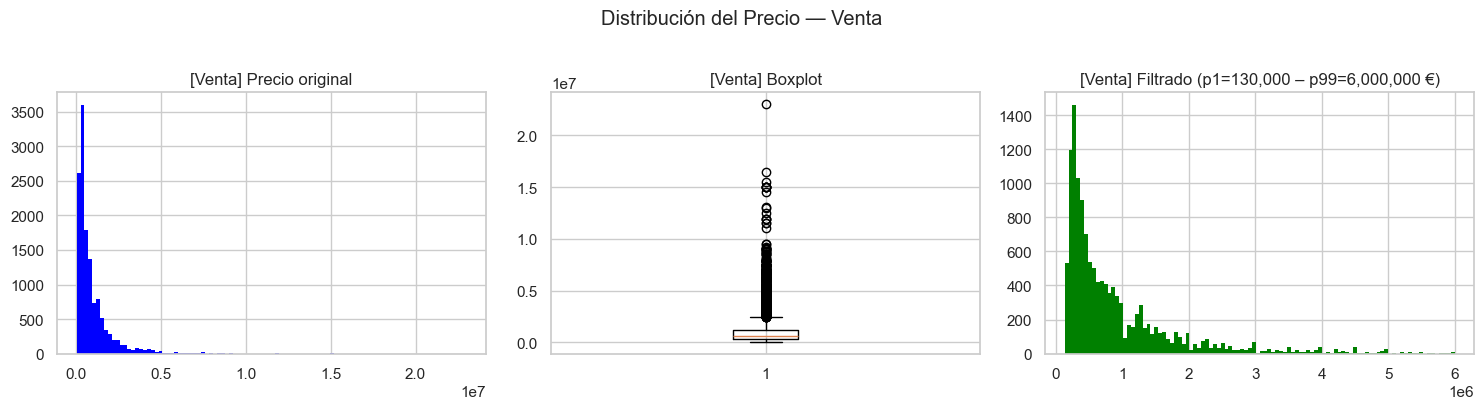

575
35000


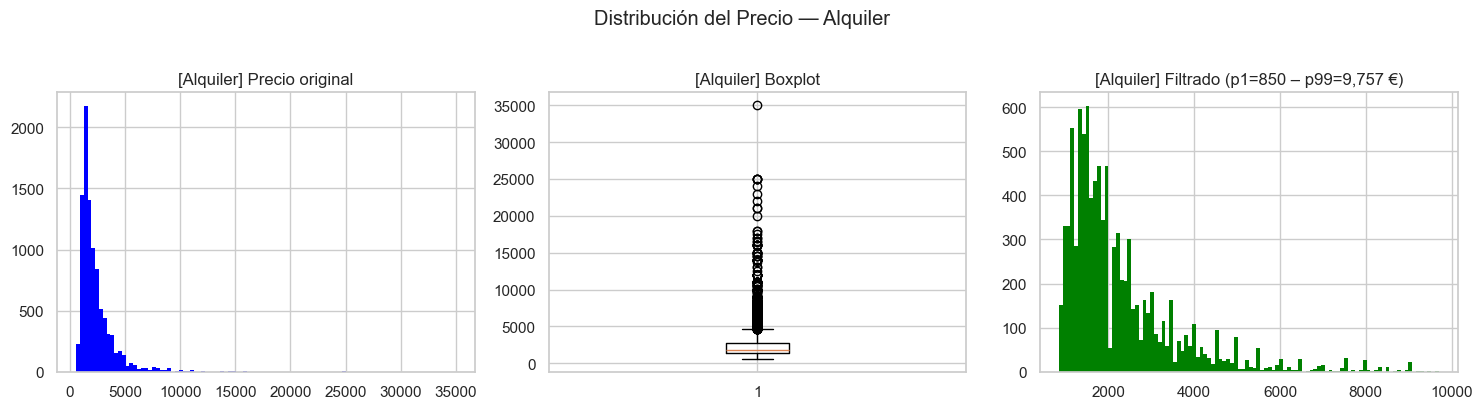

In [7]:
for nombre, df in datasets.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    print(df["Precio"].min())
    print(df["Precio"].max())
    axes[0].hist(df["Precio"], bins=100, color="blue", edgecolor="none")
    axes[0].set_title(f"[{nombre}] Precio original")

    axes[1].boxplot(df["Precio"])
    axes[1].set_title(f"[{nombre}] Boxplot")

    q1, q99 = df["Precio"].quantile([0.01, 0.99])
    df_filtrado = df[(df["Precio"] >= q1) & (df["Precio"] <= q99)]
    axes[2].hist(df_filtrado["Precio"], bins=100, color="green", edgecolor="none")
    axes[2].set_title(f"[{nombre}] Filtrado (p1={q1:,.0f} – p99={q99:,.0f} €)")

    plt.suptitle(f"Distribución del Precio — {nombre}", y=1.02)
    plt.tight_layout()
    plt.show()

## 3. Limpieza de los datasets
En un primer paso quitamos individuos que si les falta esa columna sería inútiles. También quitamos pisos repetidos.
En un segundo paso filtramos solo los outliers del percentil 99, ya que es la zona donde se ubican los outliers. 
En un tercer paso quitamos columnas que no aportan nada.
Y en un cuarto paso quitamos columnas con muchos nulos o con valores iguales para todos los datos.

In [8]:
def limpiar_dataset(df, nombre_mercado):
    print(f"\n[{nombre_mercado.upper()}] Iniciando limpieza...")
    df_limpio = df.copy()
    print(f"  -> Dimensiones iniciales: {df_limpio.shape}")

    # 1. Nulos críticos y duplicados
    filas_inicio = len(df_limpio)
    df_limpio = df_limpio.dropna(subset=['Precio', 'lat', 'lon', 'Superficie'])
    filas_sin_nulos = len(df_limpio)
    nulos_eliminados = filas_inicio - filas_sin_nulos
    
    df_limpio = df_limpio.drop_duplicates(subset=['lat', 'lon', 'Precio', 'Superficie'], keep='first')
    duplicados_eliminados = filas_sin_nulos - len(df_limpio)
    
    print(f"  -> Paso 1: Eliminadas {nulos_eliminados} filas por nulos críticos.")
    print(f"  -> Paso 1: Eliminadas {duplicados_eliminados} filas por ser duplicadas.")

    # 2. Filtrado de outliers (percentil 99)
    def filtrar_outliers(data, col):
        q_high = data[col].quantile(0.99)
        return data[col] <= q_high

    filas_antes_outliers = len(df_limpio)
    mascara = filtrar_outliers(df_limpio, 'Precio')
    df_limpio = df_limpio[mascara]
    outliers_eliminados = filas_antes_outliers - len(df_limpio)
    
    print(f"  -> Paso 2: Eliminadas {outliers_eliminados} filas por ser outliers en 'Precio' (> P99).")

    # 3. Fuga de datos e identificadores
    cols_fuga = ['id', 'Nombre', 'Direccion', 'Tipo_OSM', 'geometry', 'Precio_m2', 
                 'Media_precio_venta', 'Media_precio_m2_venta', 
                 'Media_precio_alquiler', 'Media_precio_m2_alquiler']
    
    cols_a_borrar = [c for c in cols_fuga if c in df_limpio.columns]
    df_limpio = df_limpio.drop(columns=cols_a_borrar)
    print(f"  -> Paso 3: Eliminadas {len(cols_a_borrar)} columnas por riesgo de fuga o identificadores.")
    if cols_a_borrar:
        print(f"     Columnas: {cols_a_borrar}")

    # 4. Columnas con demasiados nulos (>40%) o varianza cero (>99% mismo valor)
    cols_nulos = df_limpio.columns[df_limpio.isnull().mean() > 0.40].tolist()
    cols_zero_var = [col for col in df_limpio.columns if df_limpio[col].value_counts(normalize=True).iloc[0] > 0.99]
    
    df_limpio = df_limpio.drop(columns=cols_nulos + cols_zero_var)
    
    print(f"  -> Paso 4: Eliminadas {len(cols_nulos)} columnas por exceso de nulos (>40%).")
    if cols_nulos:
        print(f"     Columnas: {cols_nulos}")
        
    print(f"  -> Paso 4: Eliminadas {len(cols_zero_var)} columnas por varianza cero (>99%).")
    if cols_zero_var:
        print(f"     Columnas: {cols_zero_var}")

    print(f"  -> Dimensiones finales: {df_limpio.shape}")
    return df_limpio

df_venta_limpio = limpiar_dataset(df_venta, "Venta")
df_alquiler_limpio = limpiar_dataset(df_alquiler, "Alquiler")

datasets_limpios = {
    "Venta":    (df_venta,    df_venta_limpio),
    "Alquiler": (df_alquiler, df_alquiler_limpio),
}


[VENTA] Iniciando limpieza...
  -> Dimensiones iniciales: (13354, 78)
  -> Paso 1: Eliminadas 0 filas por nulos críticos.
  -> Paso 1: Eliminadas 438 filas por ser duplicadas.
  -> Paso 2: Eliminadas 128 filas por ser outliers en 'Precio' (> P99).
  -> Paso 3: Eliminadas 6 columnas por riesgo de fuga o identificadores.
     Columnas: ['id', 'Nombre', 'Direccion', 'Tipo_OSM', 'geometry', 'Precio_m2']
  -> Paso 4: Eliminadas 0 columnas por exceso de nulos (>40%).
  -> Paso 4: Eliminadas 2 columnas por varianza cero (>99%).
     Columnas: ['Equipamiento', 'Cocina']
  -> Dimensiones finales: (12788, 70)

[ALQUILER] Iniciando limpieza...
  -> Dimensiones iniciales: (9641, 78)
  -> Paso 1: Eliminadas 0 filas por nulos críticos.
  -> Paso 1: Eliminadas 214 filas por ser duplicadas.
  -> Paso 2: Eliminadas 94 filas por ser outliers en 'Precio' (> P99).
  -> Paso 3: Eliminadas 6 columnas por riesgo de fuga o identificadores.
     Columnas: ['id', 'Nombre', 'Direccion', 'Tipo_OSM', 'geometry', 

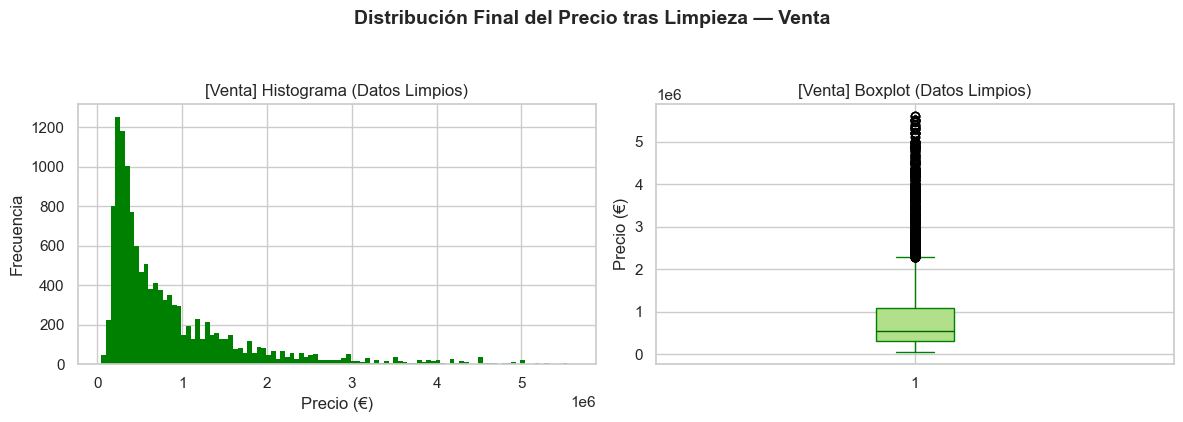

✅ Resumen Venta Limpio:
   · Viviendas finales: 12,788
   · Precio Mínimo: 47,000 €
   · Precio Máximo: 5,600,000 €



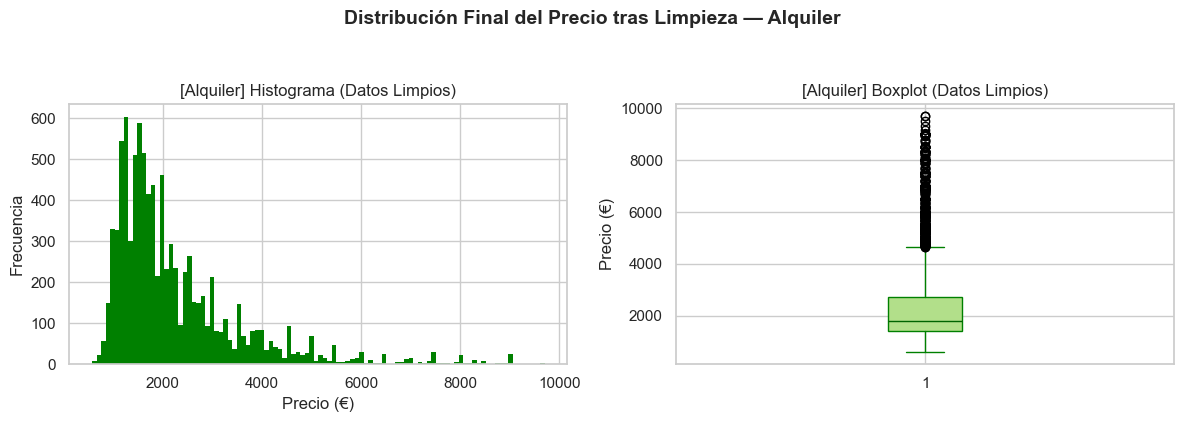

✅ Resumen Alquiler Limpio:
   · Viviendas finales: 9,333
   · Precio Mínimo: 575 €
   · Precio Máximo: 9,700 €



In [ ]:
for nombre, (df_original, df_limpio) in datasets_limpios.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 1. Histograma de los datos limpios
    axes[0].hist(df_limpio["Precio"], bins=100, color="green", edgecolor="none")
    axes[0].set_title(f"[{nombre}] Histograma (Datos Limpios)")
    axes[0].set_xlabel("Precio (€)")
    axes[0].set_ylabel("Frecuencia")

    # 2. Boxplot de los datos limpios
    axes[1].boxplot(df_limpio["Precio"], patch_artist=True, 
                    boxprops=dict(facecolor="#b2df8a", color="green"),
                    medianprops=dict(color="darkgreen"),
                    whiskerprops=dict(color="green"),
                    capprops=dict(color="green"))
    axes[1].set_title(f"[{nombre}] Boxplot (Datos Limpios)")
    axes[1].set_ylabel("Precio (€)")

    plt.suptitle(f"Distribución Final del Precio tras Limpieza — {nombre}", y=1.05, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Imprimimos un pequeño resumen debajo de la gráfica
    print(f" Resumen {nombre} Limpio:")
    print(f"   · Precio Mínimo: {df_limpio['Precio'].min():,.0f} €")
    print(f"   · Precio Máximo: {df_limpio['Precio'].max():,.0f} €\n")

## 4. Análisis de categoricos
Usamos el test kruskal en vez de ANOVA, ya que ANOVA requiere el supuesto de normalidad y nuestros datos no lo cumplen.

In [9]:
def analizar_y_limpiar_categoricas_kruskal(df, nombre_mercado):
    print(f"TEST KRUSKAL: MERCADO DE {nombre_mercado.upper()}")
    
    # Trabajamos sobre una copia para aislar el proceso
    df_temp_process = df.copy()

    # Identificación de variables no numéricas
    cols_cat = df_temp_process.select_dtypes(include=['object', 'str', 'bool']).columns.tolist()

    # 2. Análisis estadístico de varianza (ANOVA)
    print(f"{'COLUMNA':<20} | {'ÚNICOS':<8} | {'P-VALOR':<10} | {'ESTADO'}")
    print("-" * 60)
    
    for col in cols_cat:
        unicos = df_temp_process[col].nunique()
        df_test = df_temp_process.dropna(subset=[col, 'Precio'])
        
        # Agrupación de la variable objetivo según categorías
        grupos = [grupo['Precio'].values for nombre, grupo in df_test.groupby(col)]
        
        if len(grupos) > 1:
            f_stat, p_valor = stats.kruskal(*grupos)
            
            estado = "OK"
            if p_valor >= 0.05:
                estado = "DESCARTAR (p-valor alto)"
            
            if unicos > 100:
                if estado == "OK":
                    estado = "ELIMINAR (Alta cardinalidad)"
                else:
                    estado += " + ALTA CARDINALIDAD"
                
            print(f"{col:<20} | {unicos:<8} | {p_valor:<10.5f} | {estado}")

    # 3. Eliminación de variables con alta cardinalidad y ruido
    cols_alta_card = ['Calle', 'Tipo_Via', 'Barrio', 'dist_al_edificio']
    df_final = df_temp_process.drop(columns=[c for c in cols_alta_card if c in df_temp_process.columns])

    # 4. Resumen de variables para One-Hot Encoding
    cat_definitivas = df_final.select_dtypes(include=['object', 'str', 'bool']).columns.tolist()
    print("\nVariables categóricas retenidas para el modelo:")
    print(cat_definitivas)
    
    return df_final

df_venta_limpio = analizar_y_limpiar_categoricas_kruskal(df_venta_limpio, "Venta")
df_alquiler_limpio = analizar_y_limpiar_categoricas_kruskal(df_alquiler_limpio, "Alquiler")

TEST KRUSKAL: MERCADO DE VENTA
COLUMNA              | ÚNICOS   | P-VALOR    | ESTADO
------------------------------------------------------------
Barrio               | 145      | 0.00000    | ELIMINAR (Alta cardinalidad)
Distrito             | 21       | 0.00000    | OK
Calle                | 5339     | 0.00000    | ELIMINAR (Alta cardinalidad)
Ventanas             | 5        | 0.00000    | OK
Ascensor             | 2        | 0.00000    | OK
Terraza              | 2        | 0.00000    | OK
Balcon               | 2        | 0.00000    | OK
Orientacion          | 5        | 0.00000    | OK
Consumo              | 8        | 0.00000    | OK
Anuncia              | 4        | 0.00000    | OK
Tipo_Via             | 146      | 0.00000    | ELIMINAR (Alta cardinalidad)

Variables categóricas retenidas para el modelo:
['Distrito', 'Ventanas', 'Ascensor', 'Terraza', 'Balcon', 'Orientacion', 'Consumo', 'Anuncia']
TEST KRUSKAL: MERCADO DE ALQUILER
COLUMNA              | ÚNICOS   | P-VALOR    | E

In [10]:
# ¿Cuántos pisos sin cocina/equipamiento hay por rango de superficie?
df_alquiler_limpio["rango_sup"]= pd.cut(df_alquiler_limpio["Superficie"], bins=[0, 30, 60, 100, 200, 9999],
                          labels=["<30", "30-60", "60-100", "100-200", ">200"])

print(df_alquiler_limpio.groupby("rango_sup")["Cocina"].value_counts(normalize=True).unstack())
print(df_alquiler_limpio.groupby("rango_sup")["Equipamiento"].value_counts(normalize=True).unstack())

df_alquiler_limpio = df_alquiler_limpio.drop(columns=["rango_sup"])

Cocina        False     True 
rango_sup                    
<30        0.051980  0.948020
30-60      0.047858  0.952142
60-100     0.062600  0.937400
100-200    0.058855  0.941145
>200       0.098507  0.901493
Equipamiento     False     True 
rango_sup                       
<30           0.116337  0.883663
30-60         0.212182  0.787818
60-100        0.335376  0.664624
100-200       0.373650  0.626350
>200          0.656716  0.343284


Visto esto, eliminaremos la variable Cocina por su escasa varianza, independientemente del p-valor. Pero para el equipamiento aunque tenga un pvalor alto, Kruskal-Wallis es un test univariante que no detecta los efectos mediados por una tercera variable, que en este caso sería la superficie. Ya que el 88% de los pisos pequeños (<30 m²) se alquilan equipados, frente a solo el 34% de los pisos grandes (>200 m²). Esta relación inversa entre equipamiento y superficie hace que los efectos se cancelen cuando el test analiza equipamiento de forma aislada. Por lo que de momento la conservamos.

In [11]:
df_alquiler_limpio = df_alquiler_limpio.drop(columns=["Cocina"])

## 5. Análisis de correlaciones
Se usa Pearson, para relaciones lineales, Spearman no asume normalidad ni linealidad, mide si existe una relación monótona entre las variables, es decir, si cuando una sube la otra tiende a subir o bajar de forma consistente, aunque no sea proporcional. Y Kendall opera de forma similar a Spearman pero es más robusto cuando hay empates en los datos o cuando el tamaño muestral es moderado.

In [12]:
def analizar_correlaciones_e_importancia(df, nombre_mercado):
    print(f"ANÁLISIS PREDICTIVO DE VARIABLES: MERCADO DE {nombre_mercado.upper()}")

    # Filtramos solo numéricas y quitamos nulos para que los algoritmos matemáticos no fallen
    df_num = df.select_dtypes(include=['int64', 'float64']).dropna()

    # 1. Pearson (Lineal)
    print("\n--- PEARSON (Relaciones Lineales) ---")
    corr_pearson = df_num.corr()['Precio'].sort_values(ascending=False)
    print("Top 5 Positivas (Suben el precio):")
    print(corr_pearson.head(6)[1:].to_string())
    print("\nTop 5 Negativas (Bajan el precio):")
    print(corr_pearson.tail(5).to_string())

    # 2. Multicolinealidad (Variables redundantes)
    print("\nAVISO: MULTICOLINEALIDAD (>0.8)")
    matriz_corr = df_num.drop(columns=['Precio']).corr().abs()
    # Desapilamos la matriz, ordenamos y quitamos los pares duplicados
    pares_altos = matriz_corr.unstack().sort_values(ascending=False).drop_duplicates()
    pares_peligrosos = pares_altos[(pares_altos > 0.8) & (pares_altos < 1.0)]
    
    if len(pares_peligrosos) > 0:
        print(pares_peligrosos.head(5).to_string())
    else:
        print("No se encontraron variables con correlación superior a 0.8.")

    # 3.1 Spearman (Si hay curvas monótonas claras)
    print("\n--- SPEARMAN (Relaciones No Lineales) ---")
    corr_spearman = df_num.corr(method='spearman')['Precio'].sort_values(ascending=False)
    print(corr_spearman.head(6)[1:].to_string())

    # 3.2 Kendall (Si son muestras pequeñas, empates o errores)
    print("\n--- KENDALL (Relaciones No Lineales) ---")
    corr_kendall = df_num.corr(method='kendall')['Precio'].sort_values(ascending=False)
    print(corr_kendall.head(6)[1:].to_string())

analizar_correlaciones_e_importancia(df_venta_limpio, "Venta")
analizar_correlaciones_e_importancia(df_alquiler_limpio, "Alquiler")

ANÁLISIS PREDICTIVO DE VARIABLES: MERCADO DE VENTA

--- PEARSON (Relaciones Lineales) ---
Top 5 Positivas (Suben el precio):
Superficie                 0.762438
Banyos                     0.745926
Num_habitaciones           0.493250
dist_min_puntos_limpios    0.333640
lat                        0.282360

Top 5 Negativas (Bajan el precio):
anio_construccion                -0.182636
cantidad_centros_dia_cerca       -0.189530
poblacion_total                  -0.197383
cantidad_centros_mayores_cerca   -0.223253
dist_min_universidades           -0.294730

AVISO: MULTICOLINEALIDAD (>0.8)
dist_min_piscinas         dist_min_polideportivos              0.911140
cantidad_piscinas_cerca   cantidad_polideportivos_cerca        0.872049
cantidad_comercios_cerca  cantidad_iglesias_cerca              0.837562
estaciones_cerca          lineas_distintas_estaciones_cerca    0.829437
dist_min_estaciones       dist_min_bibliotecas                 0.817630

--- SPEARMAN (Relaciones No Lineales) ---
Superfic

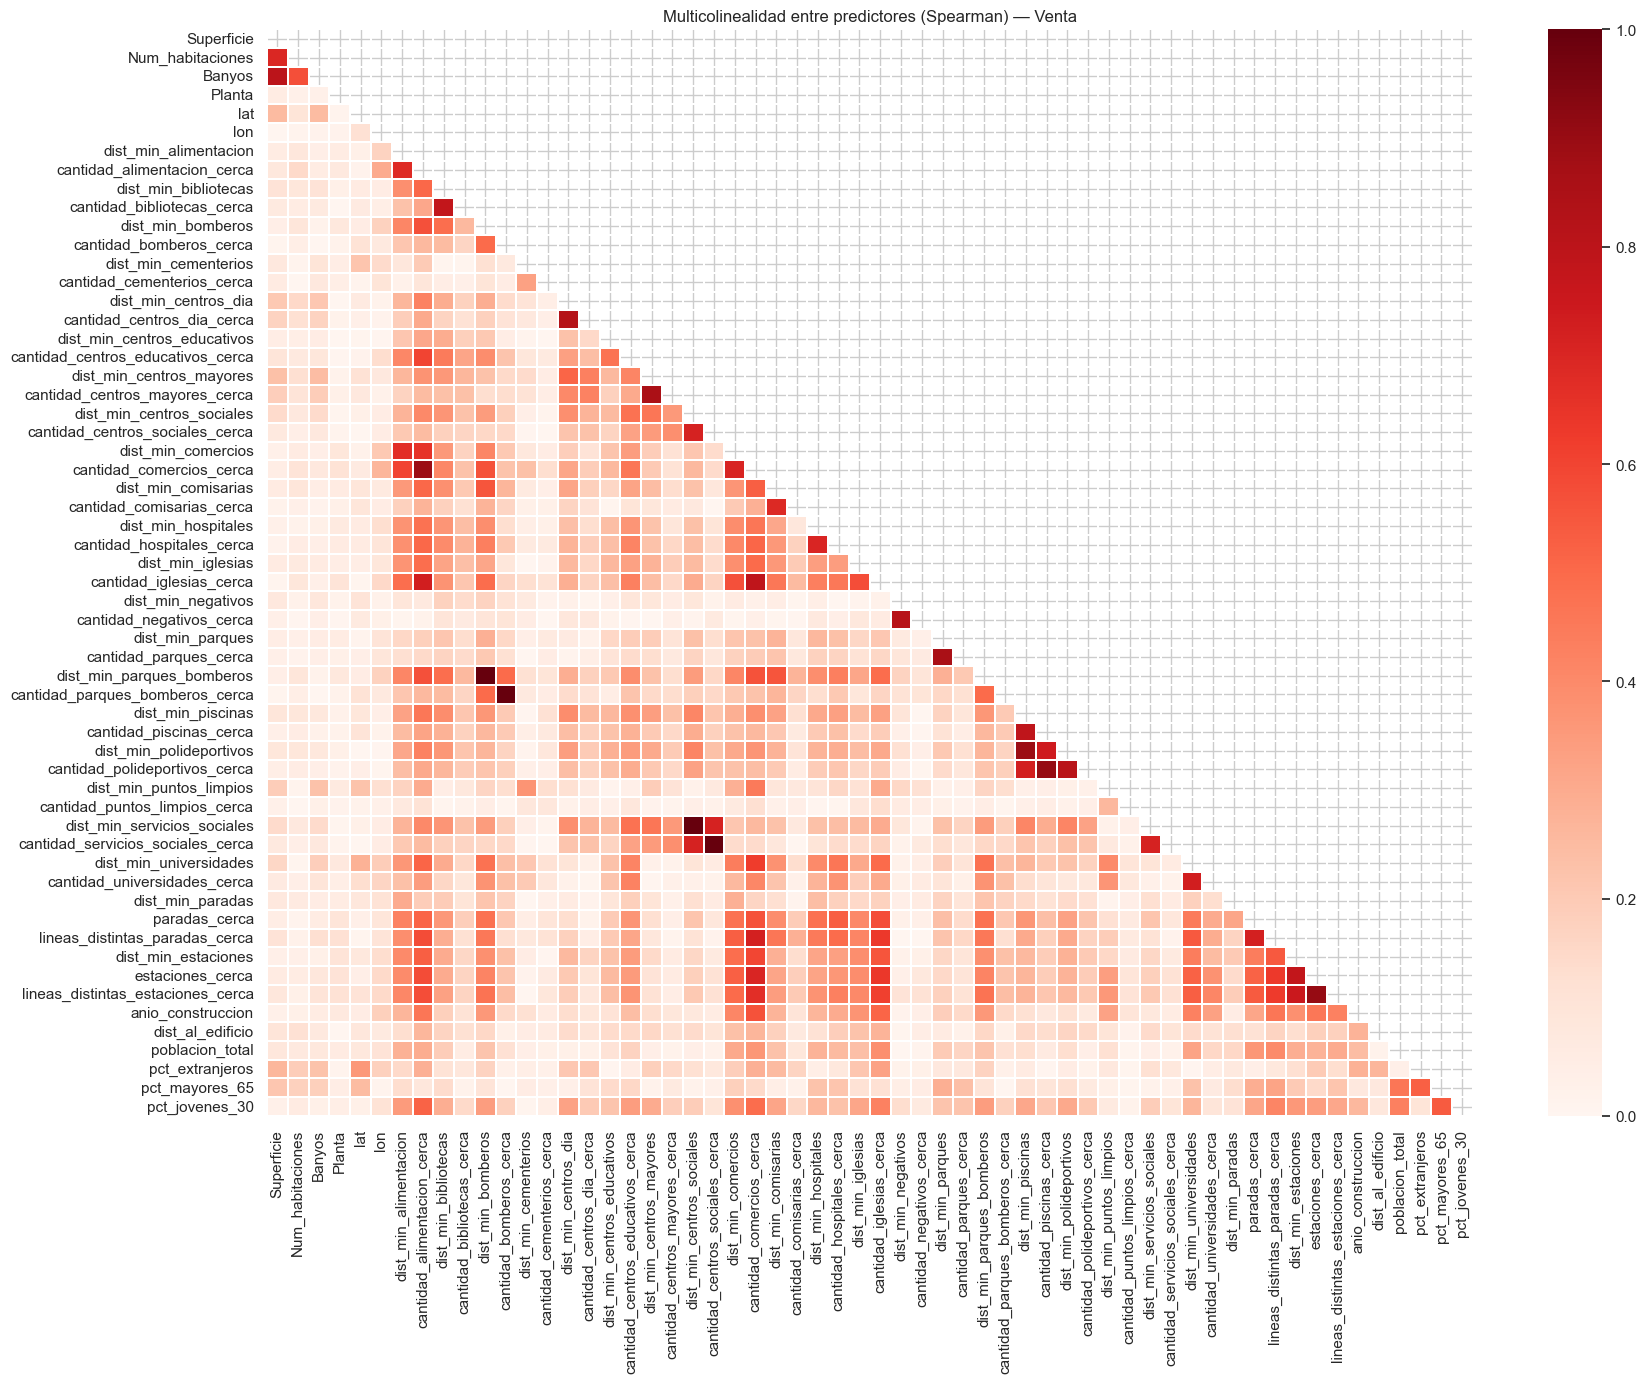


Pares con r > 0.85 — Venta:
estaciones_cerca             lineas_distintas_estaciones_cerca    0.905926
cantidad_piscinas_cerca      cantidad_polideportivos_cerca        0.904050
cantidad_alimentacion_cerca  cantidad_comercios_cerca             0.893445
dist_min_piscinas            dist_min_polideportivos              0.891079
dist_min_parques             cantidad_parques_cerca               0.857907
dist_min_centros_mayores     cantidad_centros_mayores_cerca       0.855189


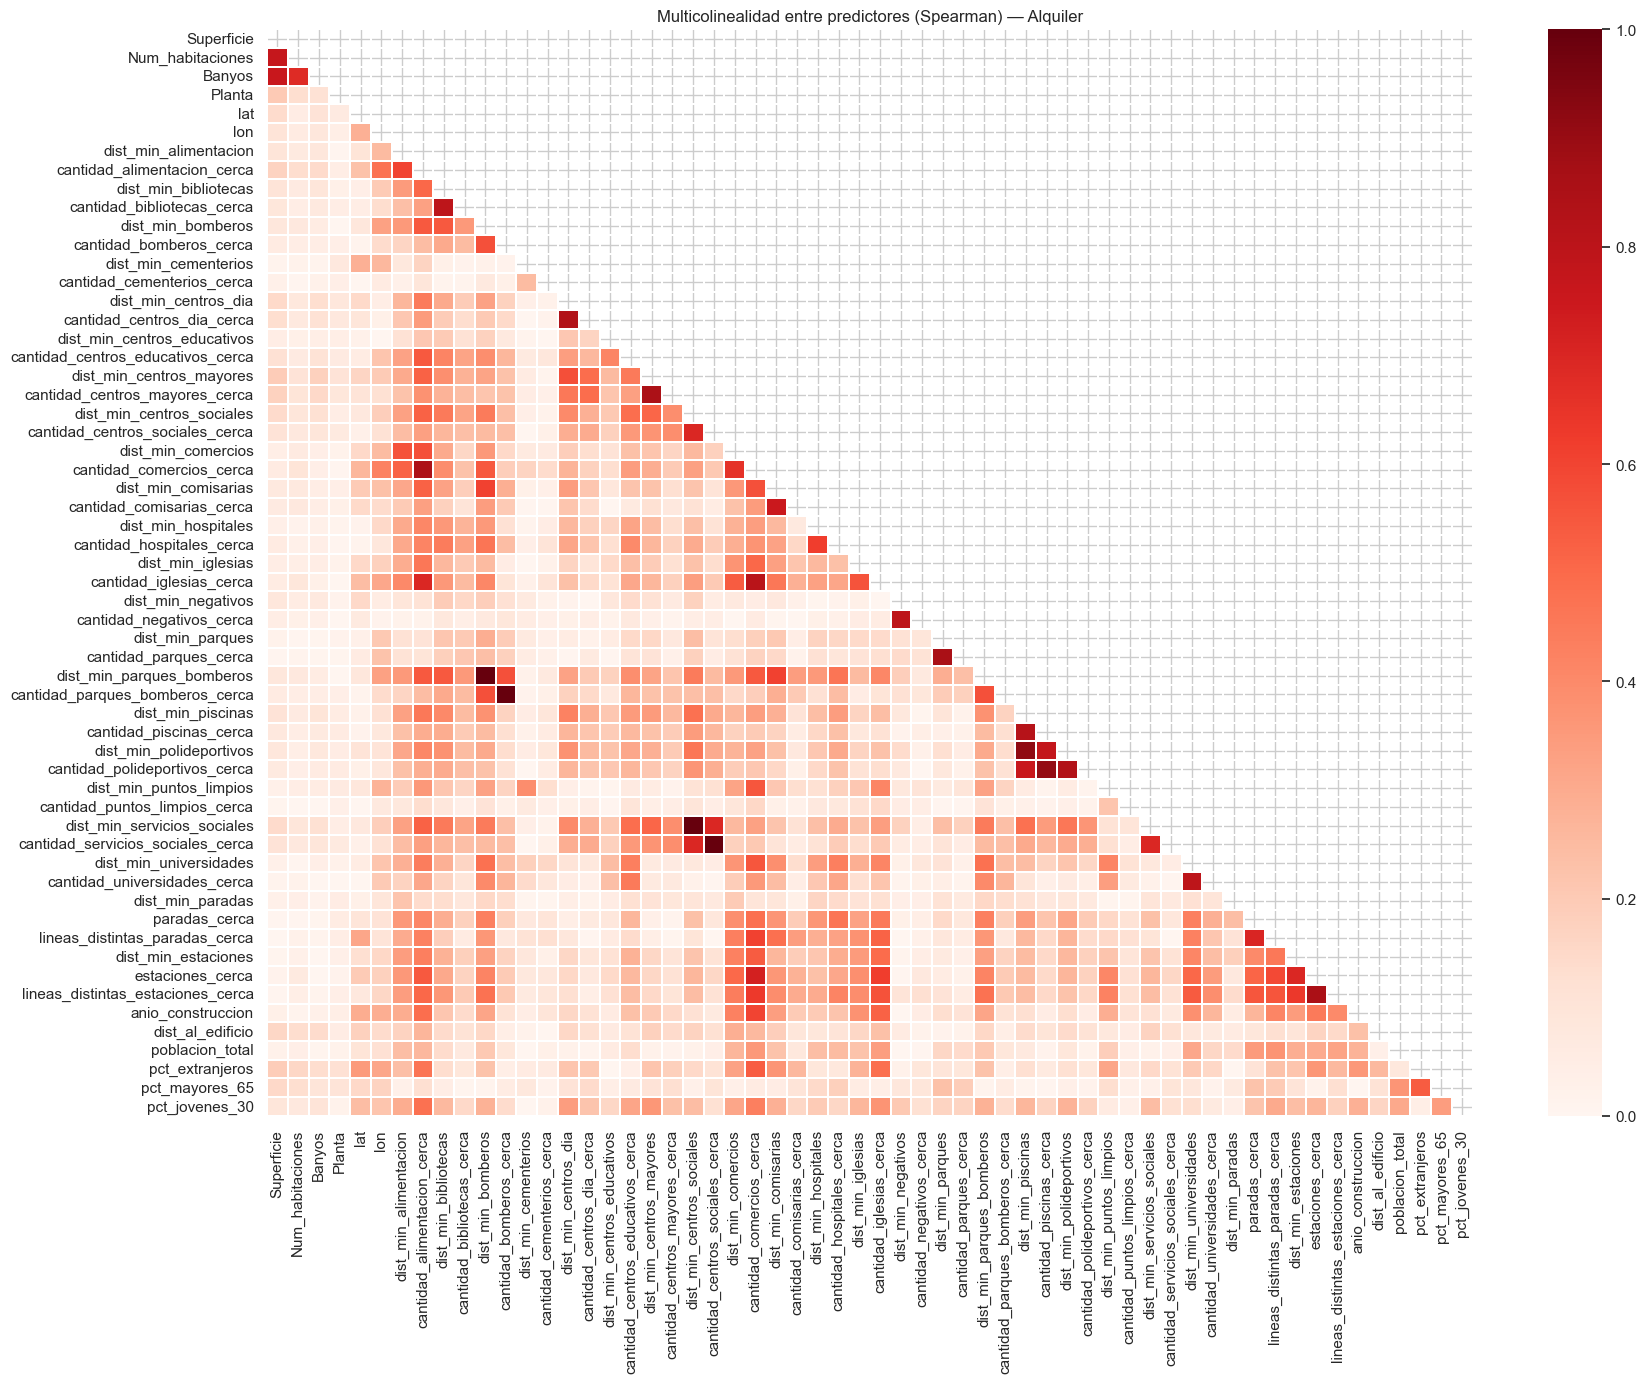


Pares con r > 0.85 — Alquiler:
dist_min_piscinas        dist_min_polideportivos              0.914965
cantidad_piscinas_cerca  cantidad_polideportivos_cerca        0.908150
dist_min_parques         cantidad_parques_cerca               0.855961
estaciones_cerca         lineas_distintas_estaciones_cerca    0.853395


In [13]:
for nombre, (df_orig, df_limp) in datasets_limpios.items():
    df_num_pred = df_limp.select_dtypes(include=["int64", "float64"]).drop(columns=["Precio"], errors="ignore")
    corr_matrix = df_num_pred.corr(method="spearman").abs()

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, mask=mask, cmap="Reds", vmin=0, vmax=1, annot=False, linewidths=0.3)
    plt.title(f"Multicolinealidad entre predictores (Spearman) — {nombre}")
    plt.tight_layout()
    plt.show()

    pares = corr_matrix.unstack()
    pares = pares[(pares > 0.85) & (pares < 1.0)].drop_duplicates().sort_values(ascending=False)
    print(f"\nPares con r > 0.85 — {nombre}:")
    print(pares.head(15).to_string())

Quitamos las columnas "dist_min_piscinas","cantidad_piscinas_cerca","estaciones_cerca" y "cantidad_alimentacion_cerca"

In [14]:
COLS_MULTICOL = [
    "dist_min_piscinas",       # Mismo equipamiento deportivo
    "cantidad_piscinas_cerca", # Mismo equipamiento deportivo
    "estaciones_cerca",              # Líneas es más informativo
    "cantidad_alimentacion_cerca",   # Comercio es más general
]

df_venta_limpio    = df_venta_limpio.drop(columns=COLS_MULTICOL)
df_alquiler_limpio = df_alquiler_limpio.drop(columns=COLS_MULTICOL)

In [15]:
print(df_venta_limpio.info())
print(df_alquiler_limpio.info())

<class 'pandas.DataFrame'>
Index: 12788 entries, 0 to 13353
Data columns (total 62 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Distrito                           12788 non-null  str    
 1   Precio                             12788 non-null  int64  
 2   Superficie                         12788 non-null  int64  
 3   Num_habitaciones                   12788 non-null  int64  
 4   Banyos                             12788 non-null  int64  
 5   Planta                             12788 non-null  float64
 6   Ventanas                           12788 non-null  str    
 7   Ascensor                           12788 non-null  bool   
 8   Terraza                            12788 non-null  bool   
 9   Balcon                             12788 non-null  bool   
 10  Orientacion                        12788 non-null  str    
 11  Consumo                            12280 non-null  str    
 12  Anunci